控制边，边决定了graph的执行顺序。
langgraph的边有：
1. 普通边（固定路由，适合执行顺序固定的流程）
2. 条件变（动态路由，根据Agent的执行状态动态的决定执行哪个节点）
3. Command（控制流，再返回state更新的同时，直接指定下一步执行哪个节点）
4. 循环边
5. 并行分支



条件边有两种路由方式：
1. 路由函数
2. 路由函数 + path_map



用户输入: 北京今天天气怎么样？
[parse_question] 解析问题: 北京今天天气怎么样？
[identify_intent] 识别意图: weather
[route_by_intent] 当前意图: weather
[weather_tool] 执行天气查询
[generate_answer] 生成最终回答
最终 State: {'question': '北京今天天气怎么样？', 'intent': 'weather', 'tool_name': 'weather_tool', 'tool_result': '北京今天晴天，气温 25℃。', 'answer': '问题：北京今天天气怎么样？\n处理结果：北京今天晴天，气温 25℃。'}
最终回答: 问题：北京今天天气怎么样？
处理结果：北京今天晴天，气温 25℃。

用户输入: 帮我查询订单状态
[parse_question] 解析问题: 帮我查询订单状态
[identify_intent] 识别意图: order
[route_by_intent] 当前意图: order
[order_tool] 执行订单查询
[generate_answer] 生成最终回答
最终 State: {'question': '帮我查询订单状态', 'intent': 'order', 'tool_name': 'order_tool', 'tool_result': '订单查询成功，当前状态为已发货。', 'answer': '问题：帮我查询订单状态\n处理结果：订单查询成功，当前状态为已发货。'}
最终回答: 问题：帮我查询订单状态
处理结果：订单查询成功，当前状态为已发货。

用户输入: 什么是 LangGraph？
[parse_question] 解析问题: 什么是 LangGraph？
[identify_intent] 识别意图: general
[route_by_intent] 当前意图: general
[general_answer] 处理通用问题
[generate_answer] 生成最终回答
最终 State: {'question': '什么是 LangGraph？', 'intent': 'general', 'tool_name': 'none', 'tool_result': '

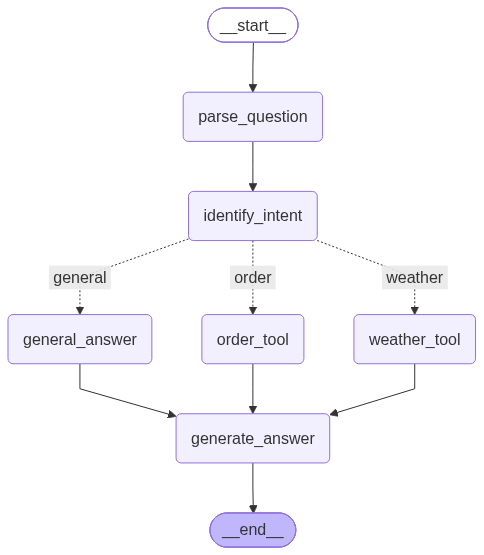

In [24]:
from IPython.display import display
"""


"""

from langgraph.constants import START, END
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Literal



# 1. 定义 State
class State(TypedDict, total=False):
    question: str
    intent: str
    tool_name: str
    tool_result: str
    answer: str

# 2. Node：解析问题
def parse_question(state: State) -> dict:
    question = state["question"].strip()

    print("[parse_question] 解析问题:", question)

    return {"question": question}


# 3. Node：识别意图
def identify_intent(state: State) -> dict:
    question = state["question"]

    if "天气" in question:
        intent = "weather"
    elif "订单" in question:
        intent = "order"
    else:
        intent = "general"

    print("[identify_intent] 识别意图:", intent)

    return {"intent": intent}


# 4. 路由函数：决定执行哪个节点，返回的结果是节点名称，表示路由到的节点
# def route_by_intent(
#     state: State,
# ) -> Literal["weather_tool", "order_tool", "general_answer"]:
#
#     intent = state["intent"]
#
#     print("[route_by_intent] 当前意图:", intent)
#
#     if intent == "weather":
#         return "weather_tool"
#
#     elif intent == "order":
#         return "order_tool"
#
#     return "general_answer"

#  路由第二种写法：路由函数+path_map：这种方式通过标签 映射到 对应的节点
def route_by_intent(
    state: State,
) -> Literal["weather_tool", "order_tool", "general_answer"]:

    intent = state["intent"]

    print("[route_by_intent] 当前意图:", intent)

    if intent == "weather":
        return "weather"

    elif intent == "order":
        return "order"

    return "general"





# 5. Node：天气工具
def weather_tool(state: State) -> dict:
    print("[weather_tool] 执行天气查询")

    return {
        "tool_name": "weather_tool",
        "tool_result": "北京今天晴天，气温 25℃。"
    }


# 6. Node：订单工具
def order_tool(state: State) -> dict:
    print("[order_tool] 执行订单查询")

    return {
        "tool_name": "order_tool",
        "tool_result": "订单查询成功，当前状态为已发货。"
    }


# 7. Node：通用回答
def general_answer(state: State) -> dict:
    print("[general_answer] 处理通用问题")

    return {
        "tool_name": "none",
        "tool_result": "该问题不需要调用外部工具。"
    }


# 8. Node：生成最终回答
def generate_answer(state: State) -> dict:
    question = state["question"]
    result = state["tool_result"]

    answer = f"问题：{question}\n处理结果：{result}"

    print("[generate_answer] 生成最终回答")

    return {"answer": answer}



# 条件变路由条件
def route_key_intent(state:State):
    intent = state["intent"]
    if intent == "weather":
        return "weather_tool"
    elif intent == "order":
        return "order_tool"
    else:
        return "general_answer"

builder = StateGraph(state_schema=State)


builder.add_node("parse_question", parse_question)
builder.add_node("identify_intent", identify_intent)

builder.add_node("weather_tool", weather_tool)
builder.add_node("order_tool", order_tool)
builder.add_node("general_answer", general_answer)
builder.add_node("generate_answer", generate_answer)


# 配置入口和普通边：
builder.add_edge(START,"parse_question")
builder.add_edge("parse_question","identify_intent")


# 条件边
# 路由函数进行条件边路由，返回的值是和节点名称进行绑定的
# builder.add_conditional_edges("identify_intent",route_by_intent)
builder.add_conditional_edges("identify_intent",route_by_intent,{
    "weather":"weather_tool",
    "order":"order_tool",
    "general":"general_answer",
})



# 分支汇合
builder.add_edge("weather_tool","generate_answer")
builder.add_edge("order_tool","generate_answer")
builder.add_edge("general_answer","generate_answer")
builder.add_edge("generate_answer",END)

graph = builder.compile()

test_questions = [
        "北京今天天气怎么样？",
        "帮我查询订单状态",
        "什么是 LangGraph？",
    ]

for question in test_questions:
    print("\n" + "=" * 45)
    print("用户输入:", question)

    result = graph.invoke({
        "question": question
    })

    print("最终 State:", result)
    print("最终回答:", result["answer"])

display(graph)


In [ ]:
# 循环边

class State(TypedDict):
    answer: str
    max_count:int


#  循环边逻辑
def check_answer(state: State):
    if len(state["answer"]) > 20:
        return "finish"
    return "retry"


builder.add_conditional_edges("check_answer",route_answer,{
    "finish":END,
    "retry":"generate_answer",
})




Command：

In [ ]:
from langgraph.types import Command


# command和条件边不同的是 command可以在更新状态的同时指定下一步
# 1. 更新intent 2. 决定执行哪个边
def identify_route(state: State) -> Command[Literal["节点1","节点2","more"]]:
    if "天气" in state["question"]:
        return Command(
            update={"intent":"weather"},
            goto="weather_tool"
        )

    return Command(
        update={"intent":"general"},
        goto="general_answer",
    )
